In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import  train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv(r"C:\Users\Shivam Mourya\ML PRO\Predicting Students Exam Score\student_habits_performance.csv")

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
# dropping NAN value rows
df = df.dropna()

In [6]:
#droping student id column because their is no use of it and may disturb model
df = df.drop(columns = "student_id")

## **Quick EDA**

In [7]:
df.describe(include = 'object')

,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909
unique,3,2,3,3,3,2
top,Male,No,Fair,High School,Good,No
freq,440,713,396,392,410,620


In [8]:
df.describe(include = 'object').columns

Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object')

In [9]:
categorical_cols = ['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation']

In [10]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("__"*50)

gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
____________________________________________________________________________________________________
part_time_job
No     713
Yes    196
Name: count, dtype: int64
____________________________________________________________________________________________________
diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
____________________________________________________________________________________________________
parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
____________________________________________________________________________________________________
internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
____________________________________________________________________________________________________
extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64
_________

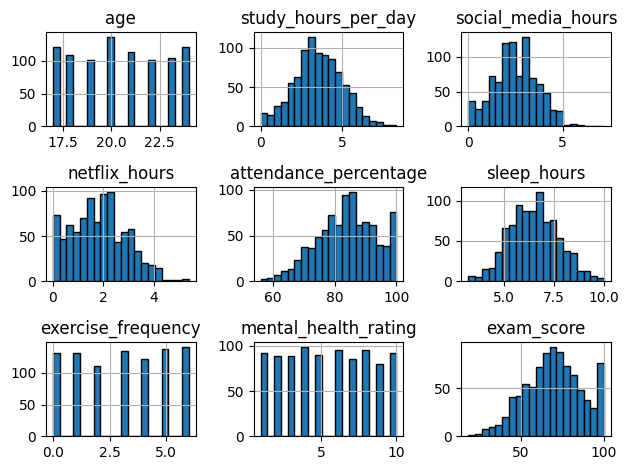

In [11]:
df.hist(bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

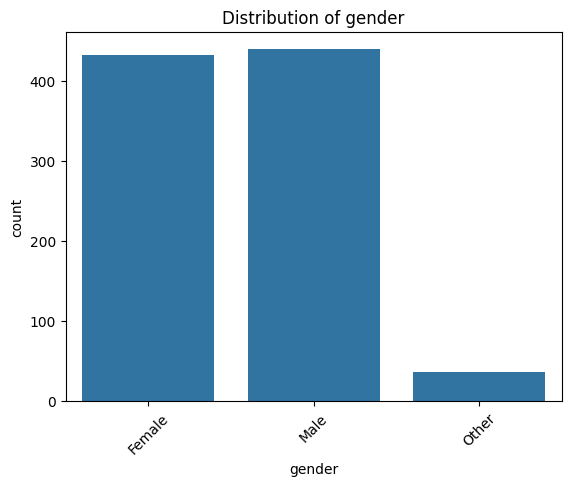

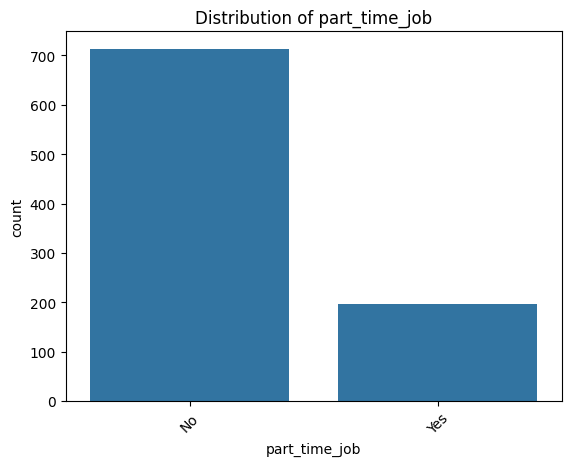

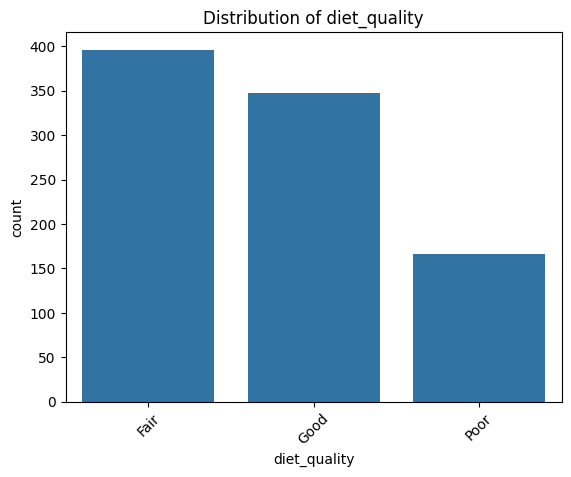

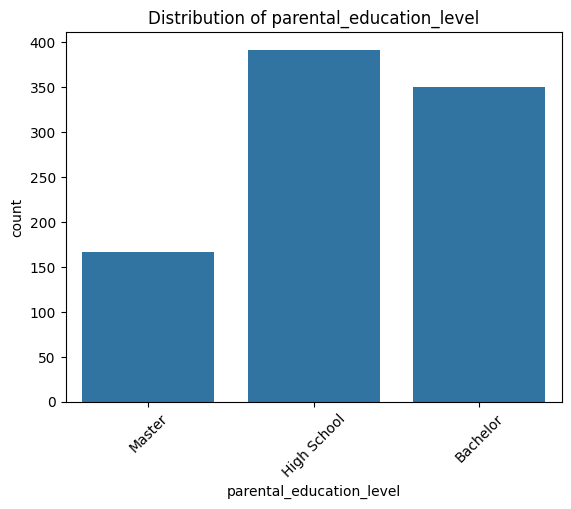

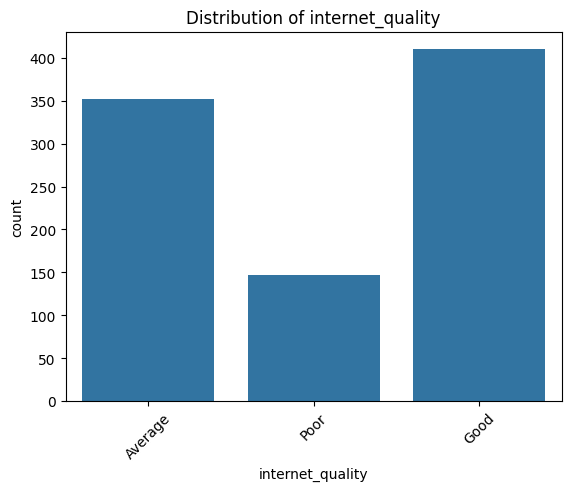

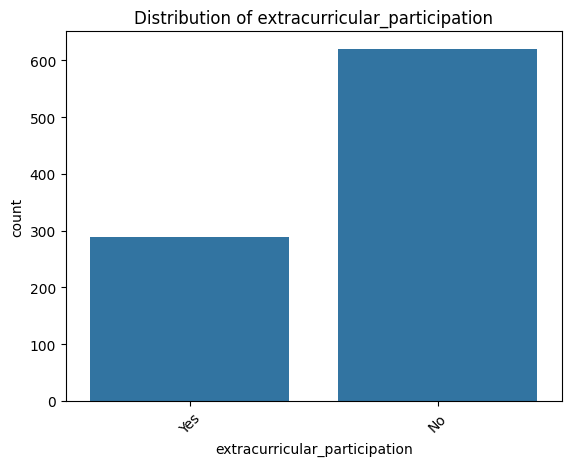

In [12]:
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    plt.show()
    

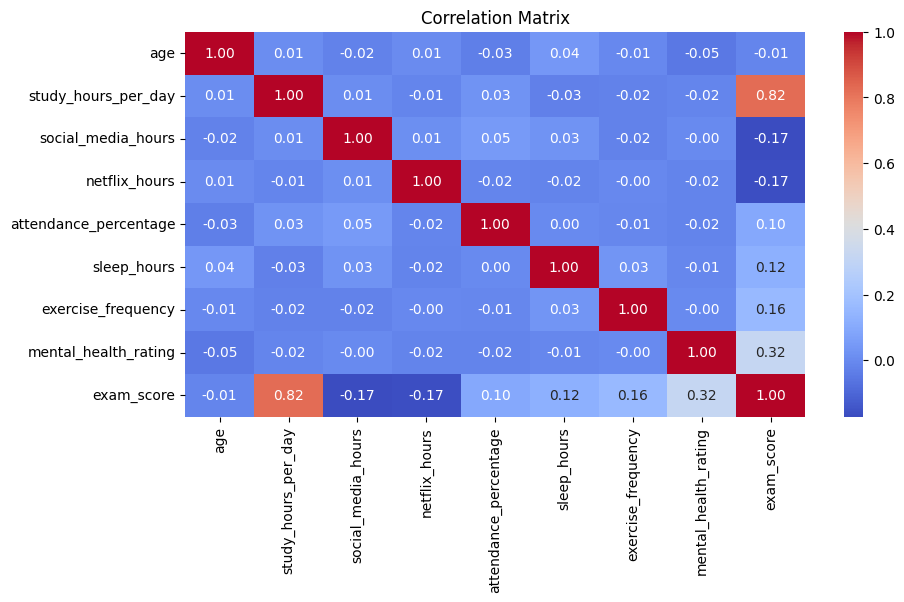

In [13]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [14]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

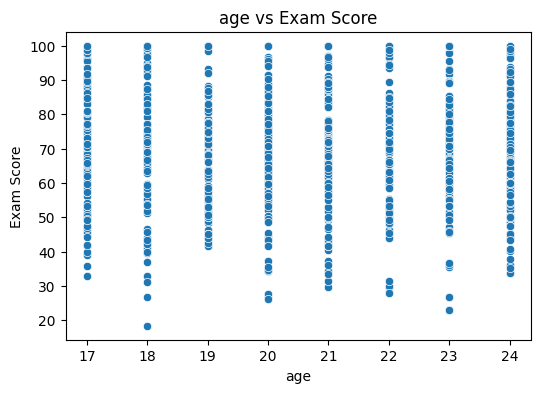

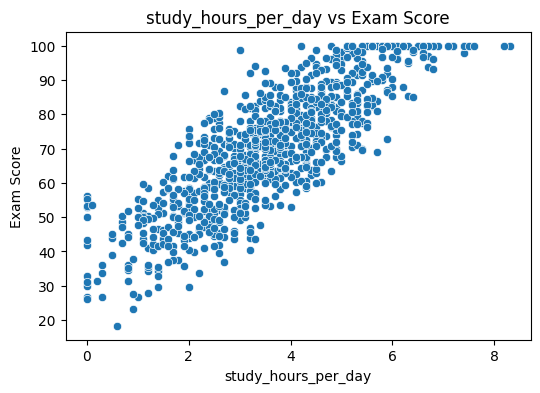

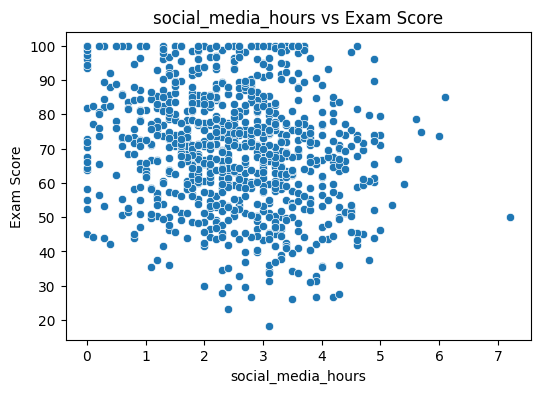

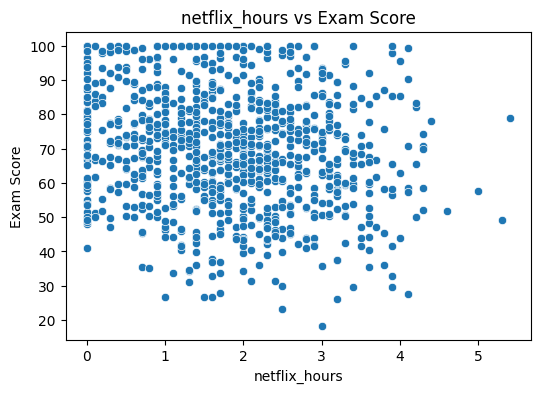

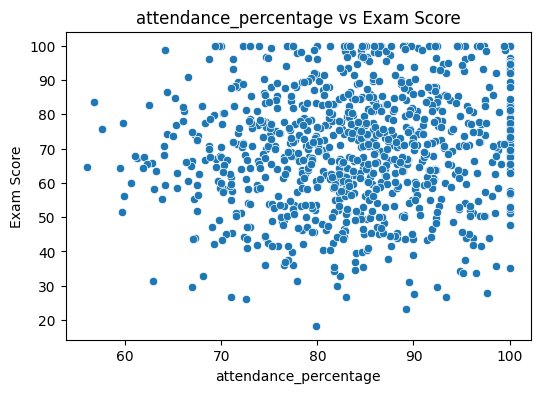

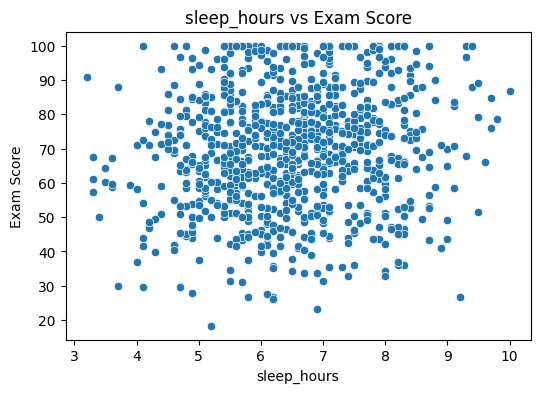

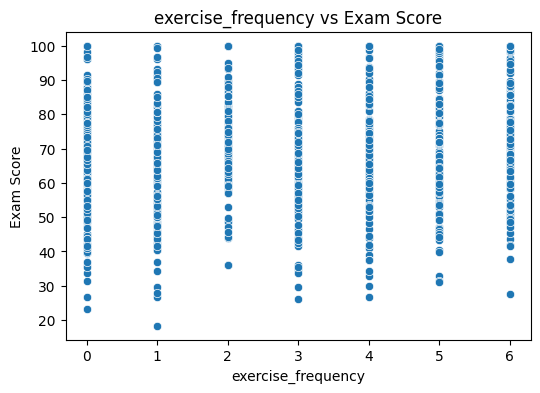

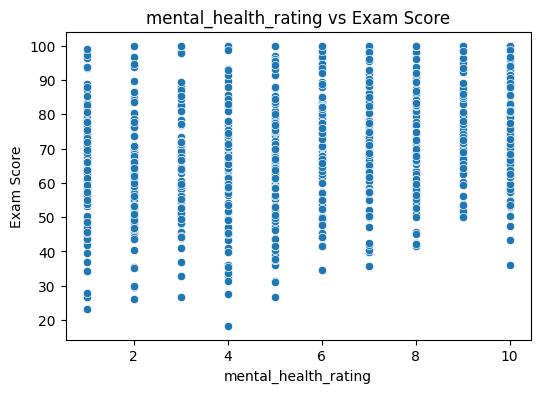

In [15]:
for feature in num_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=feature, y="exam_score")
    plt.title(f"{feature} vs Exam Score")
    plt.xlabel(feature)
    plt.ylabel("Exam Score")
    plt.show()

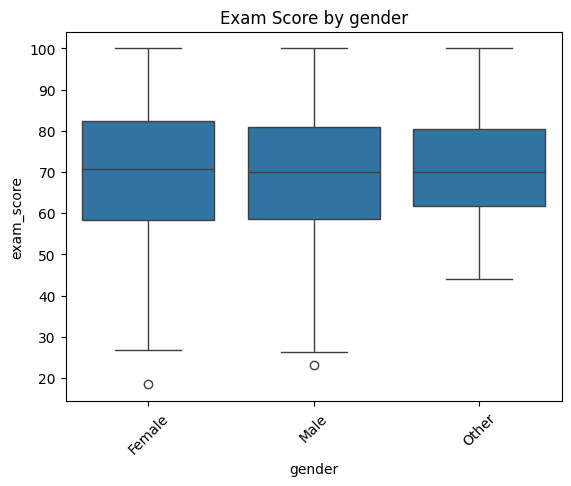

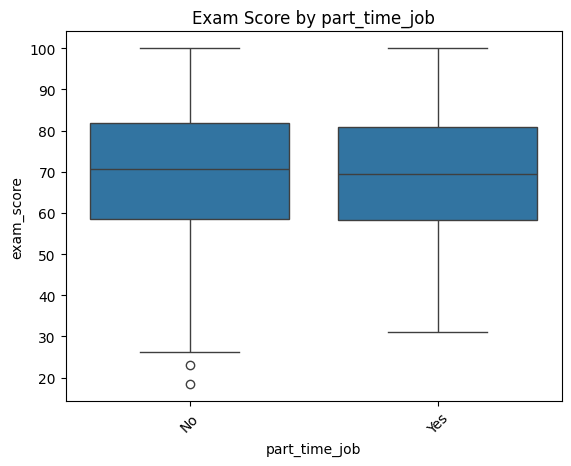

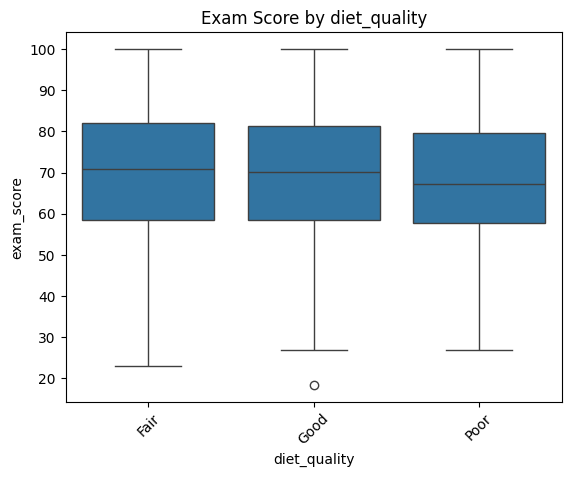

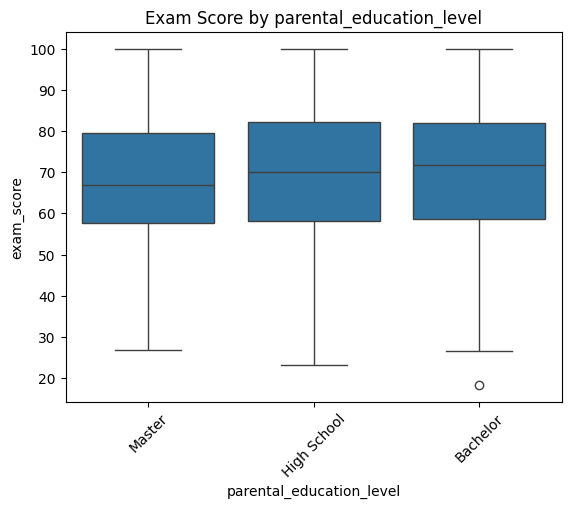

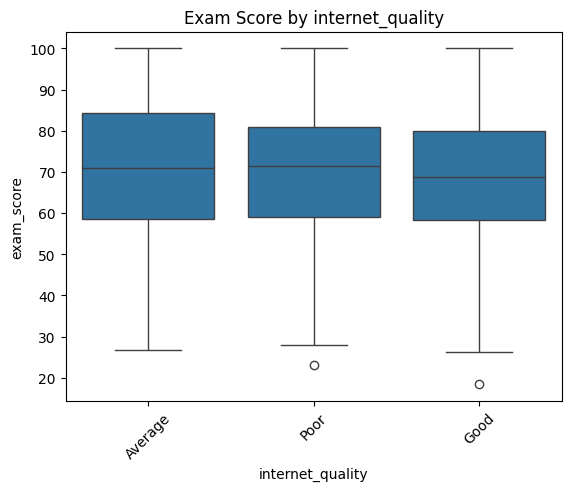

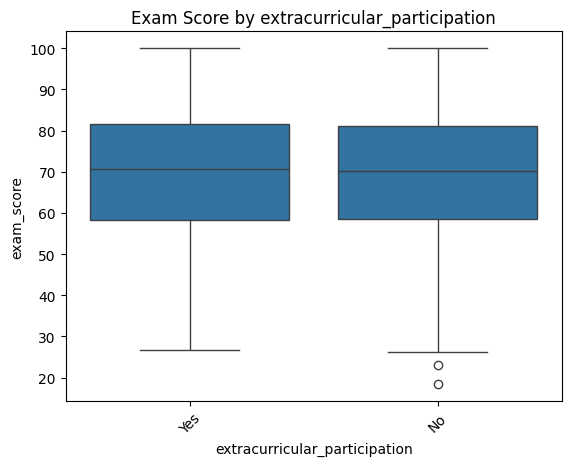

In [16]:
for col in categorical_cols:
    sns.boxplot(data=df, x=col, y="exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation =45)
    plt.show()

-----------------------

In [22]:
df.columns

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'exam_score'],
      dtype='object')

In [27]:
features = ['study_hours_per_day','sleep_hours','attendance_percentage','mental_health_rating', 'part_time_job']
target = ['exam_score']
df_model = df[features + target].copy()

In [28]:
df_model

,study_hours_per_day,sleep_hours,attendance_percentage,mental_health_rating,part_time_job,exam_score
0,0.0,8.0,85.0,8,No,56.2
1,6.9,4.6,97.3,8,No,100.0
2,1.4,8.0,94.8,1,No,34.3
3,1.0,9.2,71.0,1,No,26.8
4,5.0,4.9,90.9,1,No,66.4
...,...,...,...,...,...,...
995,2.6,7.5,77.0,6,No,76.1
996,2.9,6.8,86.0,6,Yes,65.9
997,3.0,6.5,61.9,9,No,64.4
998,5.4,7.6,100.0,1,Yes,69.7


In [33]:
labelencoder = LabelEncoder()
df_model['part_time_job'] = labelencoder.fit_transform(df_model['part_time_job'])

In [34]:
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [40]:

models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {"max_depth": [3, 5, 10], "min_samples_split": [2, 5]}
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {"n_estimators": [50, 100], "max_depth": [5, 10]}
    }
}

        

In [55]:
best_model =[]

for name, config in models.items():
    print(f"Training {name}")

    grid = GridSearchCV(config["model"],config["params"], cv=5, scoring="neg_mean_squared_error")
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    r2 = r2_score(y_test, y_pred)

    best_model.append({
        "model":name,
        "best_params": grid.best_params_,
        "rmse": rmse,
        "R2": r2
    })

Training LinearRegression
Training DecisionTree
Training RandomForest


C:\Users\Shivam Mourya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Shivam Mourya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Shivam Mourya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Shivam Mourya\AppData\Local\Programs\Python\Python313\Lib\site-packages\s

In [56]:
result_df = pd.DataFrame(best_model)
result_df.sort_values(by="rmse")

,model,best_params,rmse,R2
2,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",7.131432,0.812634
0,LinearRegression,{},7.190938,0.809494
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",7.989826,0.764814


In [57]:
import joblib

best_row = result_df.sort_values(by="rmse").iloc[1]
best_row

model          LinearRegression
best_params                  {}
rmse                   7.190938
R2                     0.809494
Name: 0, dtype: object

In [59]:
best_model_name = best_row["model"]
best_row

model          LinearRegression
best_params                  {}
rmse                   7.190938
R2                     0.809494
Name: 0, dtype: object

In [60]:
best_model_config = models[best_model_name]
best_model_config

{'model': LinearRegression(), 'params': {}}

In [61]:
final_model = best_model_config["model"]

In [62]:
final_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
joblib.dump(final_model,"best_model.pkl")


['best_model.pkl']

In [65]:
joblib.load("best_model.pkl").predict(X_test)

array([[ 56.6125347 ],
       [ 50.42847388],
       [ 68.01649762],
       [ 74.59529628],
       [ 85.98146352],
       [ 63.08078629],
       [ 80.04701348],
       [ 89.92801771],
       [ 62.76704043],
       [ 71.53075848],
       [ 54.77872093],
       [ 83.1293514 ],
       [ 55.50712337],
       [ 56.84795774],
       [ 83.44386551],
       [ 76.90551635],
       [ 50.09576014],
       [ 90.10938622],
       [ 83.16135013],
       [ 72.9566029 ],
       [ 80.61992577],
       [ 91.69729711],
       [ 49.28725829],
       [ 67.56464235],
       [ 81.74485353],
       [ 58.60039915],
       [102.62470515],
       [ 74.41638106],
       [ 61.46176878],
       [ 91.82549796],
       [ 56.40314637],
       [ 81.34776381],
       [ 57.45595147],
       [ 64.13092859],
       [ 64.48227953],
       [ 68.37208385],
       [ 89.69195799],
       [ 45.77718556],
       [ 62.717919  ],
       [ 78.07562614],
       [ 61.85054984],
       [ 79.30877704],
       [ 70.5947591 ],
       [ 66

### **App**

In [71]:
import streamlit as st
import numpy as np
import joblib 
import warnings
warnings.filterwarnings("ignore")

model = joblib.load("best_model.pkl")

st.title("Student Exam Score Predictor")

study_hours = st.slider("Study Hours per Day", 0.0, 12.0, 2.0)
attendance = st.slider("Attendance Percentage", 0.0, 100.0, 80.0)
mental_health = st.slider("Mental Health rating (1-10)", 1, 10, 5)
sleep_hours = st.slider("Sleep Hours per Night", 0.0, 12.0, 7.0)
part_time_job = st.selectbox("Part-Time Job", ["No", "Yes"])

ptj_encoded = 1 if part_time_job == "Yes" else 0

if st.button("Predict Exam Score"):
    input_data = np.array([[study_hours, attendence, mental_health, sleep_hours, ptj_encoded]])
    prediction = model.predict(input_data)[0]

    prediction = max(0, min(100, prediction))

    st.success(f"Predicted Exam Score: {prediction:.2f}")

2026-04-02 18:21:09.932 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 18:21:10.082 
  command:

    streamlit run C:\Users\Shivam Mourya\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-02 18:21:10.083 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 18:21:10.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 18:21:10.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 18:21:10.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 18:21:10.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-0

In [73]:
import nbformat

nb = nbformat.read("notebook.ipynb", as_version=4)

code_cells = [cell['source'] for cell in nb.cells if cell.cell_type == 'code']

with open("only_code.py", "w") as f:
    f.write("\n\n".join(code_cells))